Установка и импорт библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam


Загрузка данных

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print('Train:', x_train.shape, y_train.shape)
print('Test: ', x_test.shape, y_test.shape)


Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


Предобработка данных.
Нормализуем пиксели в диапазон [0, 1]


In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

Визуализация примеров

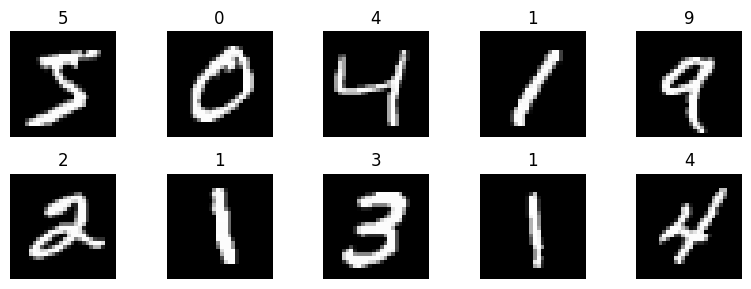

In [ ]:
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.tight_layout()
plt.show()

Архитектура модели

In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()
x_train.shape, y_train.shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

((60000, 28, 28), (60000,))

Компиляция модели

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Обучение

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8451 - loss: 0.5421 - val_accuracy: 0.9680 - val_loss: 0.1193
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9650 - loss: 0.1175 - val_accuracy: 0.9747 - val_loss: 0.0918
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9776 - loss: 0.0755 - val_accuracy: 0.9772 - val_loss: 0.0759
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9847 - loss: 0.0512 - val_accuracy: 0.9763 - val_loss: 0.0825
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9893 - loss: 0.0363 - val_accuracy: 0.9795 - val_loss: 0.0752
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9928 - loss: 0.0254 - val_accuracy: 0.9817 - val_loss: 0.0663
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9938 - loss: 0.0200 - val_accuracy: 0.9822 - val_loss: 0.0691
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9954 - loss: 0.0139 - val_accuracy: 0.

Оценка на тесте

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

Test loss: 0.074454665184021
Test accuracy: 0.9805999994277954


Графики обучения (loss/accuracy)

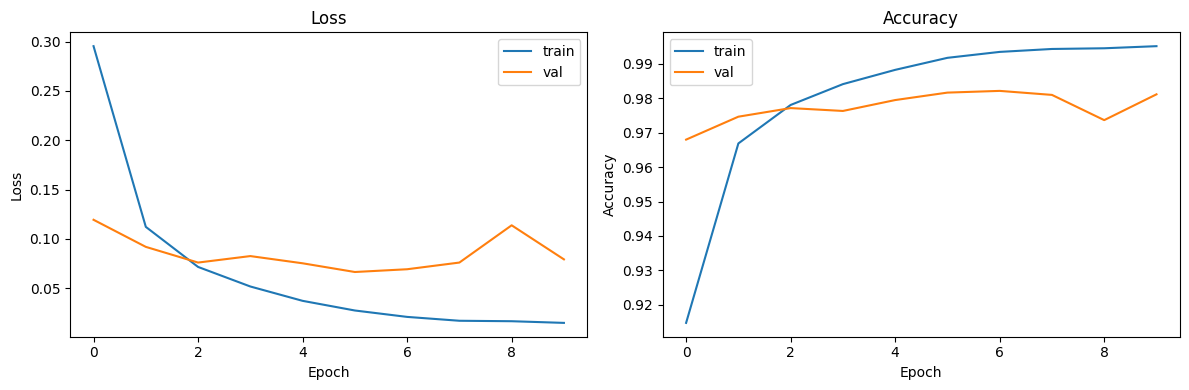

In [ ]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Предсказания модели

In [ ]:
proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(proba, axis=1)

Случайные изображения с предсказаниями

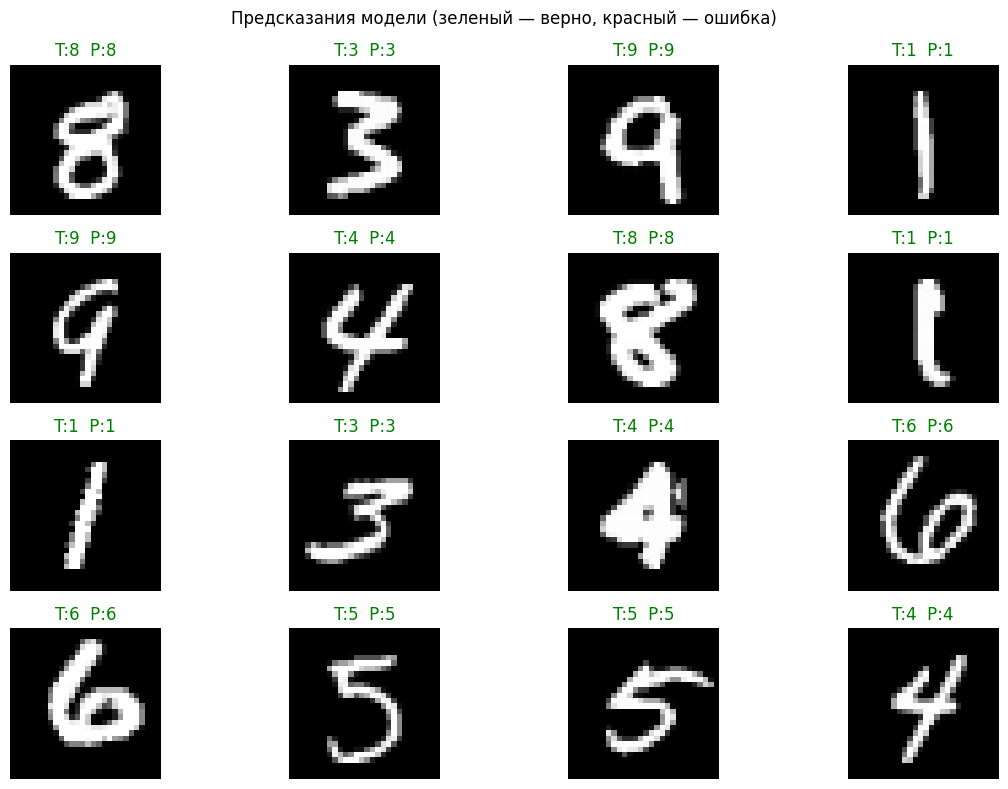

In [ ]:
plt.figure(figsize=(12, 8))

indices = random.sample(range(len(x_test)), 16)

for i, idx in enumerate(indices):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_test[idx], cmap='gray')

    true_label = y_test[idx]
    pred_label = y_pred[idx]

    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'T:{true_label}  P:{pred_label}', color=color)
    plt.axis('off')

plt.suptitle('Предсказания модели (зеленый — верно, красный — ошибка)')
plt.tight_layout()
plt.show()


Примеры неправильных классификаций

Ошибок: 194


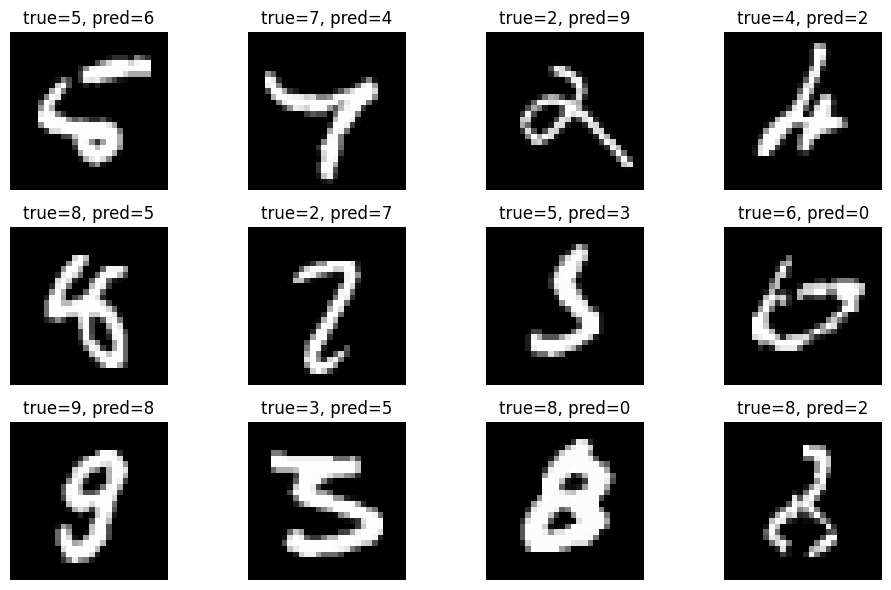

In [ ]:
wrong_idx = np.where(y_pred != y_test)[0]
print('Ошибок:', len(wrong_idx))

plt.figure(figsize=(10, 6))
for i in range(12):
    idx = wrong_idx[i]
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f'true={y_test[idx]}, pred={y_pred[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()
